# Task 2: EDM UNet + Tikhonov Regularization — Memorization Study

Train a UNet with EDM preconditioning (Karras et al. 2022) on multiband Matérn data.

**Two experiments:**
1. **Sampling-time (ad-hoc score damping):** modify score denominator to `σ² + c` at inference.
   This is NOT true Tikhonov for a learned UNet — it only matches the closed-form GMM solution.
2. **Training-time (correct per Baptista et al. 2025):** add a penalty
   `c · λ(σ) · ||D_θ − x_noisy||² / σ²` to the training loss. The shared `λ(σ)` weight
   cancels in the stationary condition, giving `s* = s_true / (1 + c/σ²)`, which matches
   the GMM Tikhonov denominator `σ² + c`.
   Sample with the standard score `(D_θ - x) / σ²` (no sampling-time modification needed).

In [2]:
import sys, os, math, copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# -- path setup --
repo_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
src_dir = os.path.join(repo_root, 'src')
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import diffusion_score_models as score_models
from multiband_data_utils import (
    generate_multiband_dataset_postmask,
    make_radial_band_mask,
    radial_bandpass,
    make_radial_k_grid,
)
from edm import EDMPrecond, EDMScoreWrapper, train_edm

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'device: {device}')

device: cpu


In [3]:
# ── Data generation (same as task1) ──
components = [
    {"name": "coarse", "length_scale": 2.0,  "s": 2.0, "sigma_sq": 1.0, "band": (0.5, 4.0)},
    {"name": "mid1",   "length_scale": 6.0,  "s": 2.0, "sigma_sq": 1.0, "band": (4.0, 10.0)},
    {"name": "mid2",   "length_scale": 12.0, "s": 2.0, "sigma_sq": 1.0, "band": (10.0, 18.0)},
    {"name": "fine",   "length_scale": 24.0, "s": 2.0, "sigma_sq": 1.0, "band": (18.0, 32.0)},
]

result = generate_multiband_dataset_postmask(
    num_samples=200, grid_size=128, components=components,
    weights=[1.0, 0.8, 0.8, 1.2], seed=42, normalize=True,
)
bands = result.get('bands', {c['name']: c['band'] for c in components})
x_all = result['combined']  # (200, 128, 128)

N_TRAIN = 32
N = 128
x_train_img = x_all[:N_TRAIN].to(device)            # (32, 128, 128)
train_data_flat = x_train_img.reshape(N_TRAIN, -1)   # (32, 16384)

print(f'x_train_img: {x_train_img.shape}, train_data_flat: {train_data_flat.shape}')
print(f'sigma_data (std of training data): {train_data_flat.std().item():.4f}')

x_train_img: torch.Size([32, 128, 128]), train_data_flat: torch.Size([32, 16384])
sigma_data (std of training data): 0.9982


In [4]:
# ── SmallUNet architecture (identical to task1) ──

class SinusoidalEmbedding(nn.Module):
    """Standard sinusoidal time embedding, maps scalar t -> vector of size dim."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, dtype=torch.float32, device=t.device) / (half - 1)
        )
        args = t.float()[:, None] * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResBlock(nn.Module):
    """Conv residual block with additive time embedding."""
    def __init__(self, in_ch, out_ch, emb_dim):
        super().__init__()
        def ngroups(ch):
            for g in [8, 4, 2, 1]:
                if ch % g == 0: return g
        self.norm1    = nn.GroupNorm(ngroups(in_ch),  in_ch)
        self.conv1    = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.norm2    = nn.GroupNorm(ngroups(out_ch), out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.skip     = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb_proj(F.silu(emb))[:, :, None, None]
        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


class SmallUNet(nn.Module):
    """
    2-level U-Net: 128->64->32 (spatial), then back up.
    Predicts a denoised image given noisy input and conditioning scalar.
    """
    def __init__(self, base_channels=16, emb_dim=64):
        super().__init__()
        C, E = base_channels, emb_dim
        self.time_embed = nn.Sequential(
            SinusoidalEmbedding(E), nn.Linear(E, E*2), nn.SiLU(), nn.Linear(E*2, E)
        )
        self.conv_in = nn.Conv2d(1,   C,   3, padding=1)
        self.enc1    = ResBlock(C,   C,   E)
        self.down1   = nn.Conv2d(C,  C*2, 3, stride=2, padding=1)   # 128->64
        self.enc2    = ResBlock(C*2, C*2, E)
        self.down2   = nn.Conv2d(C*2, C*4, 3, stride=2, padding=1)  # 64->32
        self.mid     = ResBlock(C*4, C*4, E)
        self.up2     = nn.ConvTranspose2d(C*4, C*2, 2, stride=2)    # 32->64
        self.dec2    = ResBlock(C*4, C*2, E)   # skip concat
        self.up1     = nn.ConvTranspose2d(C*2, C,   2, stride=2)    # 64->128
        self.dec1    = ResBlock(C*2, C,   E)   # skip concat
        self.conv_out = nn.Conv2d(C, 1, 3, padding=1)
    def forward(self, x, t):
        emb = self.time_embed(t)
        h   = self.conv_in(x)
        h1  = self.enc1(h,  emb)
        h2  = self.enc2(self.down1(h1), emb)
        hm  = self.mid( self.down2(h2), emb)
        hu  = self.dec2(torch.cat([self.up2(hm), h2], dim=1), emb)
        hu  = self.dec1(torch.cat([self.up1(hu), h1], dim=1), emb)
        return self.conv_out(hu)


print(f'SmallUNet params: {sum(p.numel() for p in SmallUNet().parameters()):,}')

SmallUNet params: 195,697


In [5]:
# ── Train EDM UNet ──
TOTAL_STEPS   = 5000
CHECKPOINT_AT = [1000, 3000, 5000]

checkpoints = train_edm(
    train_data_flat, grid_size=N,
    total_steps=TOTAL_STEPS, checkpoint_at=CHECKPOINT_AT,
    base_channels=16, emb_dim=64,
    lr=1e-3, batch_size=N_TRAIN,   # full-batch
    P_mean=-1.2, P_std=1.2,
    seed=0, device=device,
    UNetClass=SmallUNet,
)
print(f'Checkpoints saved at steps: {list(checkpoints.keys())}')

Estimated sigma_data = 0.9982
  step 1/5000  loss=0.903392
  step 500/5000  loss=0.124095
  step 1000/5000  loss=0.109088
  >> checkpoint saved at step 1000
  step 1500/5000  loss=0.108684
  step 2000/5000  loss=0.108759
  step 2500/5000  loss=0.108282
  step 3000/5000  loss=0.087962
  >> checkpoint saved at step 3000
  step 3500/5000  loss=0.086460
  step 4000/5000  loss=0.085766
  step 4500/5000  loss=0.116231
  step 5000/5000  loss=0.079337
  >> checkpoint saved at step 5000
Checkpoints saved at steps: [1000, 3000, 5000]


In [6]:
# ── Analysis helpers (from analyze_coarse_fine_memorization.py) ──

@torch.no_grad()
def band_component(x, band, norm='forward'):
    if x.dim() == 2:
        x = x.unsqueeze(0)
    k_lo, k_hi = band
    m = make_radial_band_mask(x.shape[-1], k_lo, k_hi, device=x.device, dtype=x.dtype)
    return radial_bandpass(x, m, norm=norm)


@torch.no_grad()
def nn_by_coarse(x_gen, x_train, coarse_band):
    cg = band_component(x_gen, coarse_band).flatten(1)
    ct = band_component(x_train, coarse_band).flatten(1)
    D = torch.cdist(cg, ct)
    idx = D.argmin(dim=1)
    return idx, D.min(dim=1).values


def make_ring_masks(N, k_edges, device):
    kr = make_radial_k_grid(N, device=device)
    masks = []
    for lo, hi in zip(k_edges[:-1], k_edges[1:]):
        masks.append(((kr >= lo) & (kr < hi)).float())
    return torch.stack(masks, dim=0)


@torch.no_grad()
def ring_rel_l2(xa, xb, ring_masks, fft_norm=None, eps=1e-12):
    Xa = torch.fft.fft2(xa, dim=(-2, -1), norm=fft_norm)
    Xb = torch.fft.fft2(xb, dim=(-2, -1), norm=fft_norm)
    D = Xa - Xb
    rm = ring_masks.unsqueeze(0).to(Xa.device)
    num = (D.abs() ** 2).unsqueeze(1) * rm
    den = (Xa.abs() ** 2).unsqueeze(1) * rm
    num = num.sum(dim=(-2, -1))
    den = den.sum(dim=(-2, -1)).clamp_min(eps)
    return torch.sqrt(num / den)


@torch.no_grad()
def random_baseline_errors(xg, xtr, ring_masks, n_ref=64, fft_norm=None):
    errs = []
    for _ in range(n_ref):
        rand_idx = torch.randint(0, xtr.shape[0], (xg.shape[0],), device=xtr.device)
        errs.append(ring_rel_l2(xg, xtr[rand_idx], ring_masks, fft_norm=fft_norm))
    return torch.stack(errs, dim=0)  # (n_ref, G, K)


def ring_idx_for_band(band, k_centers):
    lo, hi = band
    return ((k_centers >= lo) & (k_centers < hi)).nonzero().squeeze(1)


# Precompute wavenumber grid and ring masks
kmax = float(make_radial_k_grid(N, device=device).max().item())
k_edges = torch.arange(0.5, kmax + 1.5, 1.0, device=device)
ring_masks = make_ring_masks(N, k_edges, device=device)
k_centers = 0.5 * (k_edges[1:] + k_edges[:-1])
coarse_r = ring_idx_for_band(bands['coarse'], k_centers)
fine_r   = ring_idx_for_band(bands['fine'],   k_centers)
print(f'Ring masks: {ring_masks.shape}, k range: [{k_centers[0]:.1f}, {k_centers[-1]:.1f}]')

Ring masks: torch.Size([91, 128, 128]), k range: [1.0, 91.0]


In [7]:
# ── Sampling-time Tikhonov sweep ──

N_GEN = 16          # 16 samples (sufficient for ratio statistics with 32 training points)
N_SDE_STEPS = 500   # 500 steps (good accuracy for VE SDE; task1 used 1000 with VP)
N_RAND_REF = 32     # 32 random baselines (stable mean; 64 is marginal improvement)

# Use the best checkpoint
best_step = max(checkpoints.keys())
precond = checkpoints[best_step]
print(f'Using checkpoint at step {best_step}')

# Set up VE_EDM diffusion model
ve_edm = score_models.VE_EDM(sigma_min=0.002, sigma_max=80.0)

# Training data reference for memorization metrics
xtr = x_train_img.detach()

C_VALUES = [0.0, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0]

sweep_results = {}  # c -> {mean_ratio, coarse_score, fine_score, samples}

for c_val in C_VALUES:
    print(f'\n--- c = {c_val} ---')
    score_wrapper = EDMScoreWrapper(precond, ve_edm.marginal_prob_std, N, c_tikhonov=c_val).to(device)

    # Same latents for fair comparison
    torch.manual_seed(42)
    latents = torch.randn(N_GEN, N*N, device=device)
    samples = ve_edm.SDEsampler(score_wrapper, latents, num_steps=N_SDE_STEPS)
    x_gen = samples.reshape(N_GEN, N, N)

    # NN matching and ratios
    idx_nn, _ = nn_by_coarse(x_gen, xtr, bands['coarse'])
    xnn = xtr[idx_nn]
    err_nn = ring_rel_l2(x_gen, xnn, ring_masks)
    err_rand = random_baseline_errors(x_gen, xtr, ring_masks, n_ref=N_RAND_REF)
    ratio = (err_nn.unsqueeze(0) / (err_rand + 1e-12)).mean(dim=0)
    mean_ratio = ratio.mean(dim=0)

    cs = ratio[:, coarse_r].mean(dim=1)
    fs = ratio[:, fine_r].mean(dim=1)
    print(f'  coarse mean ratio: {cs.mean():.4f}, fine mean ratio: {fs.mean():.4f}')

    sweep_results[c_val] = {
        'mean_ratio': mean_ratio.cpu(),
        'coarse_score': cs.mean().item(),
        'fine_score': fs.mean().item(),
        'samples': x_gen[:4].cpu(),
    }

print('\nSweep complete.')

Using checkpoint at step 5000

--- c = 0.0 ---
  coarse mean ratio: 0.8081, fine mean ratio: 0.9996

--- c = 0.001 ---
  coarse mean ratio: 0.8082, fine mean ratio: 0.9994

--- c = 0.01 ---
  coarse mean ratio: 0.8082, fine mean ratio: 0.9987

--- c = 0.05 ---
  coarse mean ratio: 0.8085, fine mean ratio: 0.9983

--- c = 0.1 ---
  coarse mean ratio: 0.8088, fine mean ratio: 0.9986

--- c = 0.5 ---
  coarse mean ratio: 0.8104, fine mean ratio: 0.9999

--- c = 1.0 ---
  coarse mean ratio: 0.8113, fine mean ratio: 1.0005

--- c = 5.0 ---
  coarse mean ratio: 0.8206, fine mean ratio: 1.0005

Sweep complete.


## Training-time Tikhonov (correct approach per Baptista et al. 2025)

The penalty `c · λ(σ) · ||D_θ − x_noisy||² / σ²` is added to the training loss, where
`λ(σ)` is the same EDM loss weight used for the denoising term. Because both terms share
the same weight, `λ` cancels in the stationary condition, giving
`s* = s_true / (1 + c/σ²)` — matching the GMM Tikhonov denominator `σ² + c`.

For each `c` we retrain the UNet from scratch with the regularized loss, then sample
with the standard score `(D_θ - x) / σ²` (no sampling-time modification needed).

In [8]:
# ── Training-time Tikhonov sweep ──
# For each c, retrain from scratch with penalty c * weight(σ) * ||D-x_noisy||^2 / σ^2.
# The weight cancels in the stationary condition, giving s* = s_true / (1 + c/σ^2).
# Then sample with the standard score (c_tikhonov=0 at sampling time).
# c=0.0 reuses the checkpoint from cell 4 (identical to unregularized training).

C_TRAIN_VALUES = [0.0, 0.001, 0.01, 0.1, 1.0, 5.0]

train_sweep_results = {}

for c_val in C_TRAIN_VALUES:
    if c_val == 0.0:
        # Reuse existing unregularized checkpoint — no need to retrain
        print(f'\n===== c_tikhonov = 0.0 (reusing cell 4 checkpoint) =====')
        trained_precond = precond
    else:
        print(f'\n===== Training with c_tikhonov = {c_val} =====')
        ckpts = train_edm(
            train_data_flat, grid_size=N,
            total_steps=TOTAL_STEPS, checkpoint_at=[TOTAL_STEPS],
            base_channels=16, emb_dim=64,
            lr=1e-3, batch_size=N_TRAIN,
            P_mean=-1.2, P_std=1.2,
            c_tikhonov=c_val,
            seed=0, device=device,
            UNetClass=SmallUNet,
        )
        trained_precond = ckpts[TOTAL_STEPS]

    # Sample with standard score (no sampling-time regularization)
    score_wrapper = EDMScoreWrapper(trained_precond, ve_edm.marginal_prob_std, N, c_tikhonov=0.0).to(device)
    torch.manual_seed(42)
    latents = torch.randn(N_GEN, N*N, device=device)
    samples = ve_edm.SDEsampler(score_wrapper, latents, num_steps=N_SDE_STEPS)
    x_gen = samples.reshape(N_GEN, N, N)

    # Memorization metrics
    idx_nn, _ = nn_by_coarse(x_gen, xtr, bands['coarse'])
    xnn = xtr[idx_nn]
    err_nn = ring_rel_l2(x_gen, xnn, ring_masks)
    err_rand = random_baseline_errors(x_gen, xtr, ring_masks, n_ref=N_RAND_REF)
    ratio = (err_nn.unsqueeze(0) / (err_rand + 1e-12)).mean(dim=0)
    mean_ratio = ratio.mean(dim=0)

    cs = ratio[:, coarse_r].mean(dim=1)
    fs = ratio[:, fine_r].mean(dim=1)
    print(f'  coarse mean ratio: {cs.mean():.4f}, fine mean ratio: {fs.mean():.4f}')

    train_sweep_results[c_val] = {
        'mean_ratio': mean_ratio.cpu(),
        'coarse_score': cs.mean().item(),
        'fine_score': fs.mean().item(),
        'samples': x_gen[:4].cpu(),
    }

print('\nTraining-time sweep complete.')


===== c_tikhonov = 0.0 (reusing cell 4 checkpoint) =====
  coarse mean ratio: 0.8081, fine mean ratio: 0.9996

===== Training with c_tikhonov = 0.001 =====
Estimated sigma_data = 0.9982
  step 1/5000  loss=0.905265
  step 500/5000  loss=0.176319
  step 1000/5000  loss=0.167207
  step 1500/5000  loss=0.151220
  step 2000/5000  loss=0.150989
  step 2500/5000  loss=0.169082
  step 3000/5000  loss=0.114824
  step 3500/5000  loss=0.126722
  step 4000/5000  loss=0.135695
  step 4500/5000  loss=0.246391
  step 5000/5000  loss=0.131804
  >> checkpoint saved at step 5000
  coarse mean ratio: 0.8140, fine mean ratio: 0.9941

===== Training with c_tikhonov = 0.01 =====
Estimated sigma_data = 0.9982
  step 1/5000  loss=0.922126
  step 500/5000  loss=0.350554
  step 1000/5000  loss=0.326377
  step 1500/5000  loss=0.280119
  step 2000/5000  loss=0.313068
  step 2500/5000  loss=0.324504
  step 3000/5000  loss=0.233414
  step 3500/5000  loss=0.250688
  step 4000/5000  loss=0.283377
  step 4500/5000  

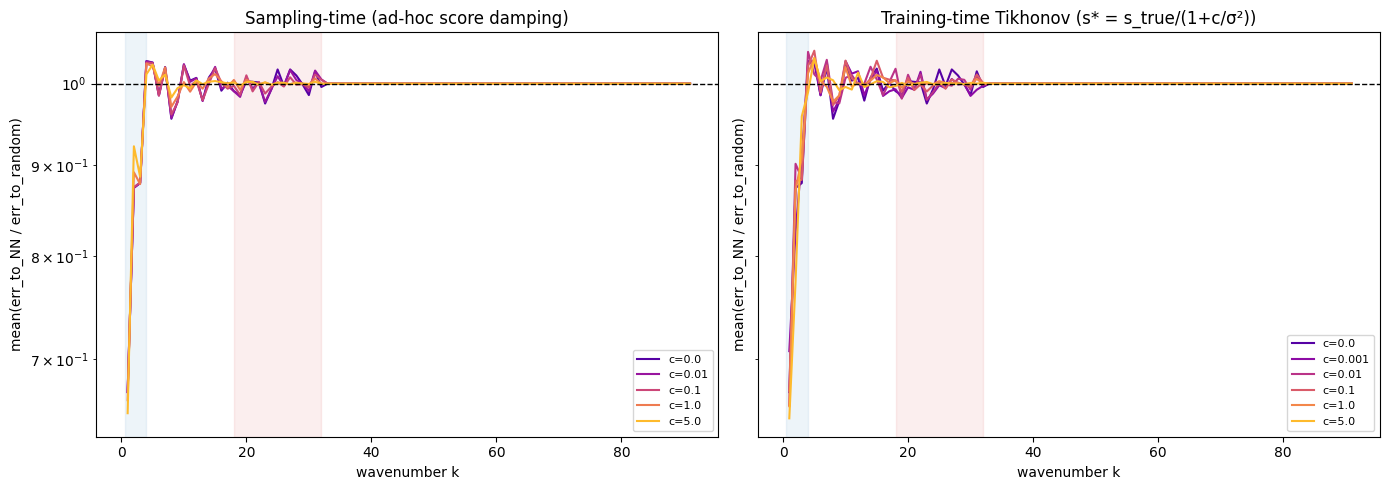


--- Coarse band mean ratio ---
     c   sampling-time   training-time
 0.000          0.8081          0.8081
 0.001          0.8082          0.8140
 0.010          0.8082          0.8153
 0.100          0.8088          0.8124
 1.000          0.8113          0.8126
 5.000          0.8206          0.7938


In [9]:
# ── Training-time vs sampling-time Tikhonov comparison ──

kc = k_centers.cpu().numpy()
cmap_train = plt.cm.plasma(np.linspace(0.15, 0.85, len(C_TRAIN_VALUES)))

# Per-wavenumber plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Left: sampling-time (ad-hoc score damping — not true Tikhonov for UNets)
compare_c = [c for c in [0.0, 0.01, 0.1, 1.0, 5.0] if c in sweep_results]
cmap_samp = plt.cm.plasma(np.linspace(0.15, 0.85, len(compare_c)))
for i, c_val in enumerate(compare_c):
    axes[0].plot(kc, sweep_results[c_val]['mean_ratio'].numpy(),
                color=cmap_samp[i], label=f'c={c_val}', linewidth=1.5)
axes[0].set_title('Sampling-time (ad-hoc score damping)')

# Right: training-time (correct Tikhonov)
for i, c_val in enumerate(C_TRAIN_VALUES):
    axes[1].plot(kc, train_sweep_results[c_val]['mean_ratio'].numpy(),
                color=cmap_train[i], label=f'c={c_val}', linewidth=1.5)
axes[1].set_title('Training-time Tikhonov (s* = s_true/(1+c/σ²))')

for ax in axes:
    ax.axhline(1.0, ls='--', color='black', lw=1)
    for bname, color in [('coarse', 'tab:blue'), ('fine', 'tab:red')]:
        lo, hi = bands[bname]
        ax.axvspan(lo, hi, color=color, alpha=0.08)
    ax.set_yscale('log')
    ax.set_xlabel('wavenumber k')
    ax.set_ylabel('mean(err_to_NN / err_to_random)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Summary: coarse score comparison
print('\n--- Coarse band mean ratio ---')
print(f'{"c":>6s}  {"sampling-time":>14s}  {"training-time":>14s}')
for c_val in C_TRAIN_VALUES:
    st = sweep_results.get(c_val, {}).get('coarse_score', float('nan'))
    tt = train_sweep_results[c_val]['coarse_score']
    print(f'{c_val:6.3f}  {st:14.4f}  {tt:14.4f}')

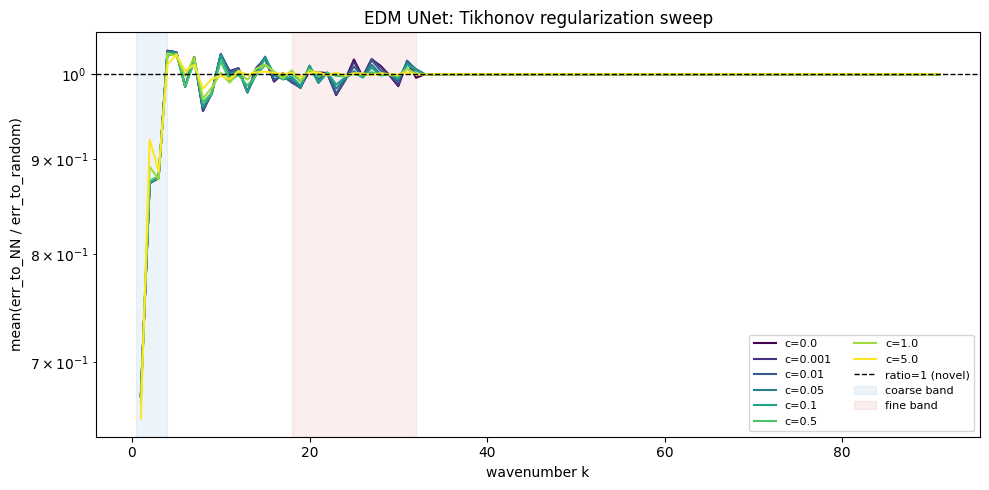

In [10]:
# ── Per-wavenumber memorization plot (main figure) ──

kc = k_centers.cpu().numpy()
cmap = plt.cm.viridis(np.linspace(0, 1, len(C_VALUES)))

fig, ax = plt.subplots(figsize=(10, 5))
for i, c_val in enumerate(C_VALUES):
    mr = sweep_results[c_val]['mean_ratio'].numpy()
    ax.plot(kc, mr, color=cmap[i], label=f'c={c_val}', linewidth=1.5)

ax.axhline(1.0, ls='--', color='black', lw=1, label='ratio=1 (novel)')
for bname, color in [('coarse', 'tab:blue'), ('fine', 'tab:red')]:
    lo, hi = bands[bname]
    ax.axvspan(lo, hi, color=color, alpha=0.08, label=f'{bname} band')

ax.set_yscale('log')
ax.set_xlabel('wavenumber k')
ax.set_ylabel('mean(err_to_NN / err_to_random)')
ax.set_title('EDM UNet: Tikhonov regularization sweep')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

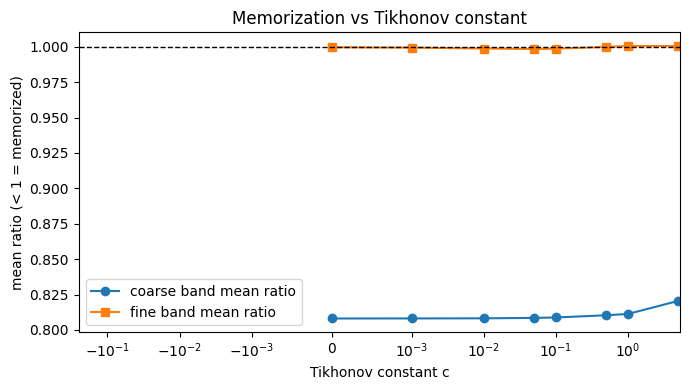

In [11]:
# ── Coarse/fine scores vs c ──

cs_vals = [sweep_results[c]['coarse_score'] for c in C_VALUES]
fs_vals = [sweep_results[c]['fine_score']   for c in C_VALUES]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(C_VALUES, cs_vals, 'o-', label='coarse band mean ratio')
ax.plot(C_VALUES, fs_vals, 's-', label='fine band mean ratio')
ax.axhline(1.0, ls='--', color='black', lw=1)
ax.set_xscale('symlog', linthresh=1e-3)
ax.set_xlabel('Tikhonov constant c')
ax.set_ylabel('mean ratio (< 1 = memorized)')
ax.set_title('Memorization vs Tikhonov constant')
ax.legend()
plt.tight_layout()
plt.show()

GMM c=0.0: coarse=0.0294
GMM c=0.001: coarse=0.0305
GMM c=0.01: coarse=0.0331
GMM c=0.05: coarse=0.0378
GMM c=0.1: coarse=0.0413
GMM c=0.5: coarse=0.0565
GMM c=1.0: coarse=0.0683
GMM c=5.0: coarse=0.1196


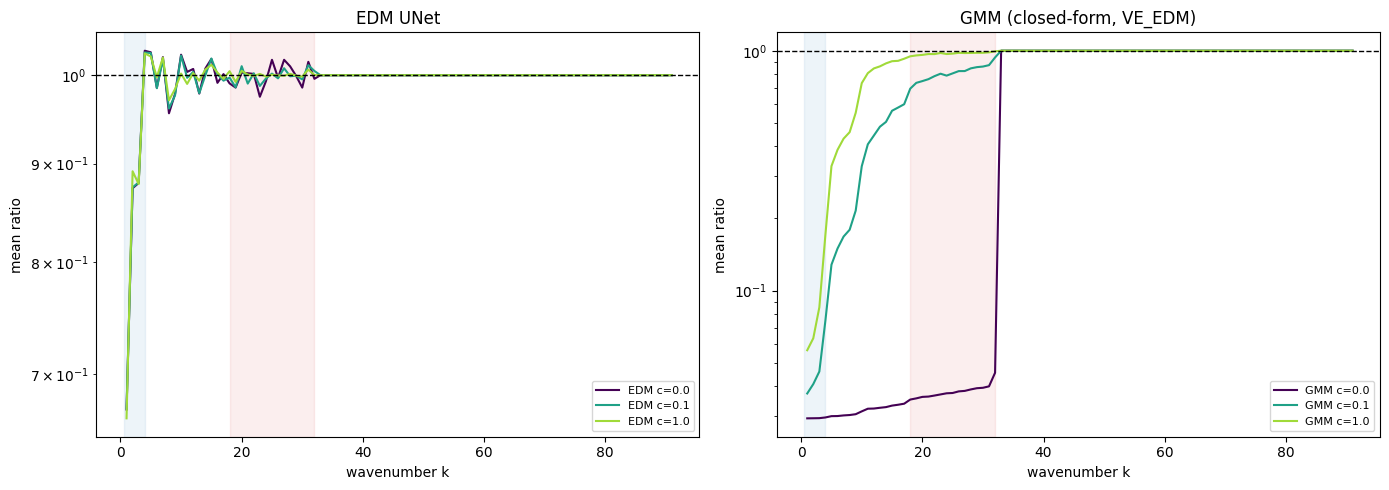

In [12]:
# ── Comparison with GMM Tikhonov (using same VE_EDM diffusion as the UNet) ──

gmm_sweep = {}
diffusion_gmm = score_models.VE_EDM(sigma_min=0.002, sigma_max=80.0)

for c_val in C_VALUES:
    if c_val == 0.0:
        score_gmm = score_models.GMM_score(
            train_data_flat, diffusion_gmm.marginal_prob_mean, diffusion_gmm.marginal_prob_std
        ).to(device)
    else:
        score_gmm = score_models.GMM_score_TikhonovRegularized(
            train_data_flat, diffusion_gmm.marginal_prob_mean,
            diffusion_gmm.marginal_prob_std, diffusion_gmm.diffusion_coeff,
            constant=c_val,
        ).to(device)

    torch.manual_seed(42)
    latents_gmm = torch.randn(N_GEN, N*N, device=device)
    samples_gmm = diffusion_gmm.SDEsampler(score_gmm, latents_gmm, num_steps=N_SDE_STEPS)
    x_gen_gmm = samples_gmm.reshape(N_GEN, N, N)

    idx_nn, _ = nn_by_coarse(x_gen_gmm, xtr, bands['coarse'])
    xnn = xtr[idx_nn]
    err_nn = ring_rel_l2(x_gen_gmm, xnn, ring_masks)
    err_rand = random_baseline_errors(x_gen_gmm, xtr, ring_masks, n_ref=N_RAND_REF)
    ratio = (err_nn.unsqueeze(0) / (err_rand + 1e-12)).mean(dim=0)
    gmm_sweep[c_val] = ratio.mean(dim=0).cpu()
    cs = ratio[:, coarse_r].mean(dim=1)
    print(f'GMM c={c_val}: coarse={cs.mean():.4f}')

# Overlay plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, c_val in enumerate([0.0, 0.1, 1.0]):
    c_idx = C_VALUES.index(c_val)
    axes[0].plot(kc, sweep_results[c_val]['mean_ratio'].numpy(),
                color=cmap[c_idx], label=f'EDM c={c_val}', linewidth=1.5)
    axes[1].plot(kc, gmm_sweep[c_val].numpy(),
                color=cmap[c_idx], label=f'GMM c={c_val}', linewidth=1.5)

for ax, title in zip(axes, ['EDM UNet', 'GMM (closed-form, VE_EDM)']):
    ax.axhline(1.0, ls='--', color='black', lw=1)
    for bname, color in [('coarse', 'tab:blue'), ('fine', 'tab:red')]:
        lo, hi = bands[bname]
        ax.axvspan(lo, hi, color=color, alpha=0.08)
    ax.set_yscale('log')
    ax.set_xlabel('wavenumber k')
    ax.set_ylabel('mean ratio')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

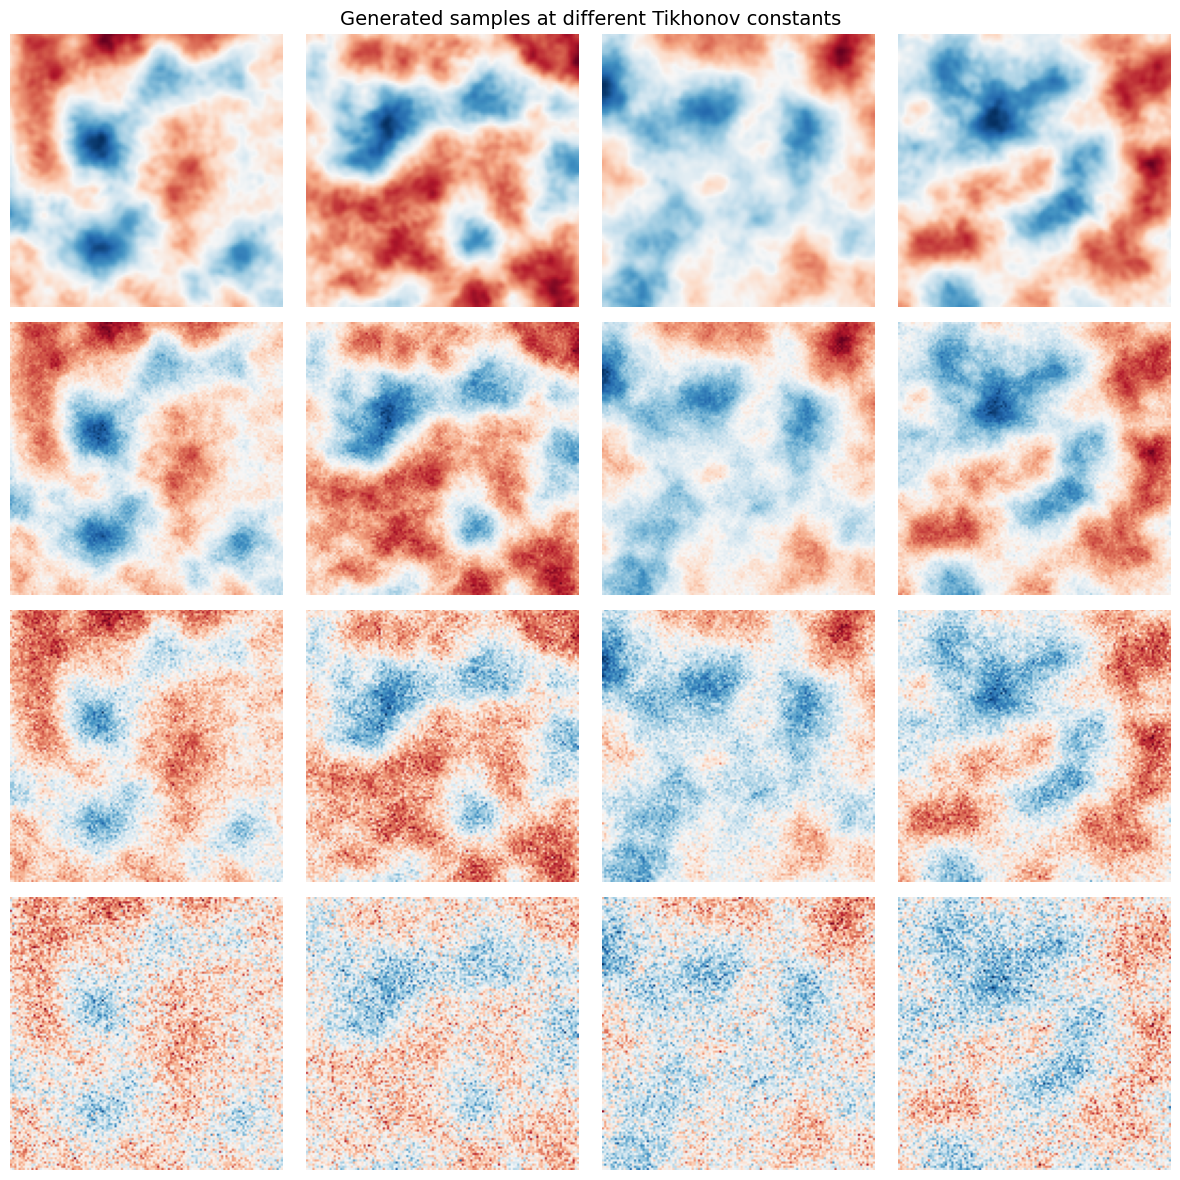

In [13]:
# ── Visual comparison of generated samples ──

show_c = [0.0, 0.01, 0.1, 1.0]
n_show = 4

fig, axes = plt.subplots(len(show_c), n_show, figsize=(3*n_show, 3*len(show_c)))
for r, c_val in enumerate(show_c):
    s = sweep_results[c_val]['samples'][:n_show]
    for col in range(n_show):
        axes[r, col].imshow(s[col].numpy(), cmap='RdBu')
        axes[r, col].axis('off')
    axes[r, 0].set_ylabel(f'c={c_val}', fontsize=12, rotation=0, labelpad=40)

plt.suptitle('Generated samples at different Tikhonov constants', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# ── Save results ──

results_dir = os.path.join(repo_root, 'results', 'data')
os.makedirs(results_dir, exist_ok=True)

save_obj = {
    'c_values': C_VALUES,
    'c_train_values': C_TRAIN_VALUES,
    'sweep_results': {c: {k: v for k, v in d.items()} for c, d in sweep_results.items()},
    'train_sweep_results': {c: {k: v for k, v in d.items()} for c, d in train_sweep_results.items()},
    'gmm_sweep': gmm_sweep,
    'k_centers': k_centers.cpu(),
    'bands': bands,
    'n_train': N_TRAIN,
    'best_step': best_step,
    'note': 'Training-time Tikhonov: penalty c*weight(s)*||D-x||^2/s^2, giving s*=s_true/(1+c/s^2). GMM uses VE_EDM.',
}
save_path = os.path.join(results_dir, 'edm_tikhonov_sweep.pt')
torch.save(save_obj, save_path)
print(f'Results saved to {save_path}')

Results saved to /Users/ishittaiyer/Desktop/Research/results/data/edm_tikhonov_sweep.pt
